# Dependencies

Pandas numpy for data handling ;scikit-learn for baseline models; beautifulsoup4, requests,newspaper3k for webscraping; nltk, spacy for text cleaning; tensorflow, pytorch for deep learning; streamlit or plotly dash for dashboards

In [2]:
pip install pandas numpy scikit-learn nltk shap tensorflow streamlit

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 0.0/49.8 kB ? eta -:--:--
     ---------------------------------------- 49.8/49.8 kB 2.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/375.9 MB 20.7 MB/s eta 0:00:19
   ---------------------------------------- 2.1/375.9 MB 26.7 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0:00:15
   ---------------------------------------- 3.1/375.9 MB 25.1 MB/s eta 0

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data

In [ ]:
'''
import kagglehub
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Path to dataset files:", path)
'''

# Data Exploration

In [2]:
import pandas as pd
fake_df=pd.read_csv("C:/Users/karth/OneDrive/Desktop/fake_news_detection/fake-and-real-news-dataset/Fake.csv")# load dataset fake
real_df=pd.read_csv("C:/Users/karth/OneDrive/Desktop/fake_news_detection/fake-and-real-news-dataset/TRUE.csv")# load dataset true
fake_df.head()
real_df.head()
fake_df["label"]="FAKE"
real_df["label"]="REAL"
df=pd.concat([fake_df,real_df],ignore_index=True)
df.head()
df=df.sample(frac=1,random_state=42).reset_index(drop=True)
print(df.head())
print("Class Distribution : ")
print(df['label'].value_counts())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date label  
0    February 13, 2017  FAKE  
1       April 5, 2017   REAL  
2  September 27, 2017   REAL  
3         May 22, 2017  FAKE  
4       June 24, 2016   REAL  
Class Distribution : 
label
FAKE    23481
REAL    21417


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB
None
title      0
text       0
subject    0
date       0
label      0
dtype: int64


fake instances - 23481, real instances - 21417 ; no null instances and no missing values

Combining title and text to simplify contents

In [4]:
df["content"]=df["title"]+" "+df["text"]
df=df[["content","label"]]
df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,FAKE
1,Trump drops Steve Bannon from National Securit...,REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,FAKE
4,Donald Trump heads for Scotland to reopen a go...,REAL


In [9]:
pip install numpy==1.26.4 --force-reinstall

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 388.9 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 461.8 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.2/15.8 MB 4.8 MB/s eta 0:00:04
   -- ------------------------------------- 1.0/15.8 MB 16.4 MB/s eta 0:00:01
   ----- ---------------------------------- 2.1/15.8 MB 22.1 MB/s eta 0:00:01
   ------- -------------------------------- 2.9/15.8 MB 18.5 MB/s eta 0:00:01
   ------- -------------------------------- 3.1/15.8 MB 20.0 MB/s eta 0:00:01
   ------- -------------------------------- 3.1/15.8 MB 20.0 MB/s eta 0:00:01
   ------- -------------------------------- 3.1/15.8 MB 20.0 MB/s eta 0:00:01
   ------- -------------------------------- 3.1/15.8 MB 20.0 MB/s eta 0:0

  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
pip install scipy==1.12.0 --force-reinstall

     ---------------------------------------- 0.0/60.4 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.4 kB ? eta -:--:--
     ------------------- ------------------ 30.7/60.4 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 60.4/60.4 kB 460.6 kB/s eta 0:00:00
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/46.2 MB 1.9 MB/s eta 0:00:25
   ---------------------------------------- 0.1/46.2 MB 2.1 MB/s eta 0:00:22
   ---------------------------------------- 0.3/46.2 MB 2.8 MB/s eta 0:00:17
   ---------------------------------------- 0.6/46.2 MB 3.6 MB/s eta 0:00:13
    --------------------------------------- 1.1/46.2 MB 5.6 MB/s eta 0:00:09
   - -------------------------------------- 2.1/46.2 MB 8.9 MB/s eta 0:00:05
   --- ------------------------------------ 3.8/46.2 MB 13.4 MB/s eta 0:00:04
   ---- ------

  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Text Cleaning + EDA (Exploratory Data Analysis)

In [5]:
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words=set(stopwords.words("english"))

def clean_text(text):
    text=text.lower()
    #remove punctutation and URLs
    text=re.sub('\[.*?\]','',text)
    text=re.sub("\\W"," ",text)
    text=re.sub(r"http\S+|www\S+|https\S+",'',text,flags=re.MULTILINE)
    text=re.sub('<.*?>+','',text)
    text=re.sub('[%s]'%re.escape(string.punctuation),'',text)
    text=re.sub('\n','',text)
    # remove stopwords
    words = text.split()
    words=[word for word in words if word not in stop_words]
    #join back to string
    return " ".join(words)
df['clean_content']=df['content'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\karth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# EDA

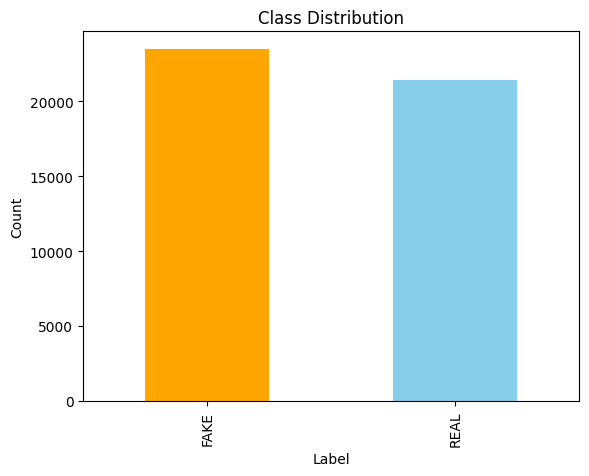

In [6]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['orange', 'skyblue'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

most common words for fake news

Text(0, 0.5, 'Count')

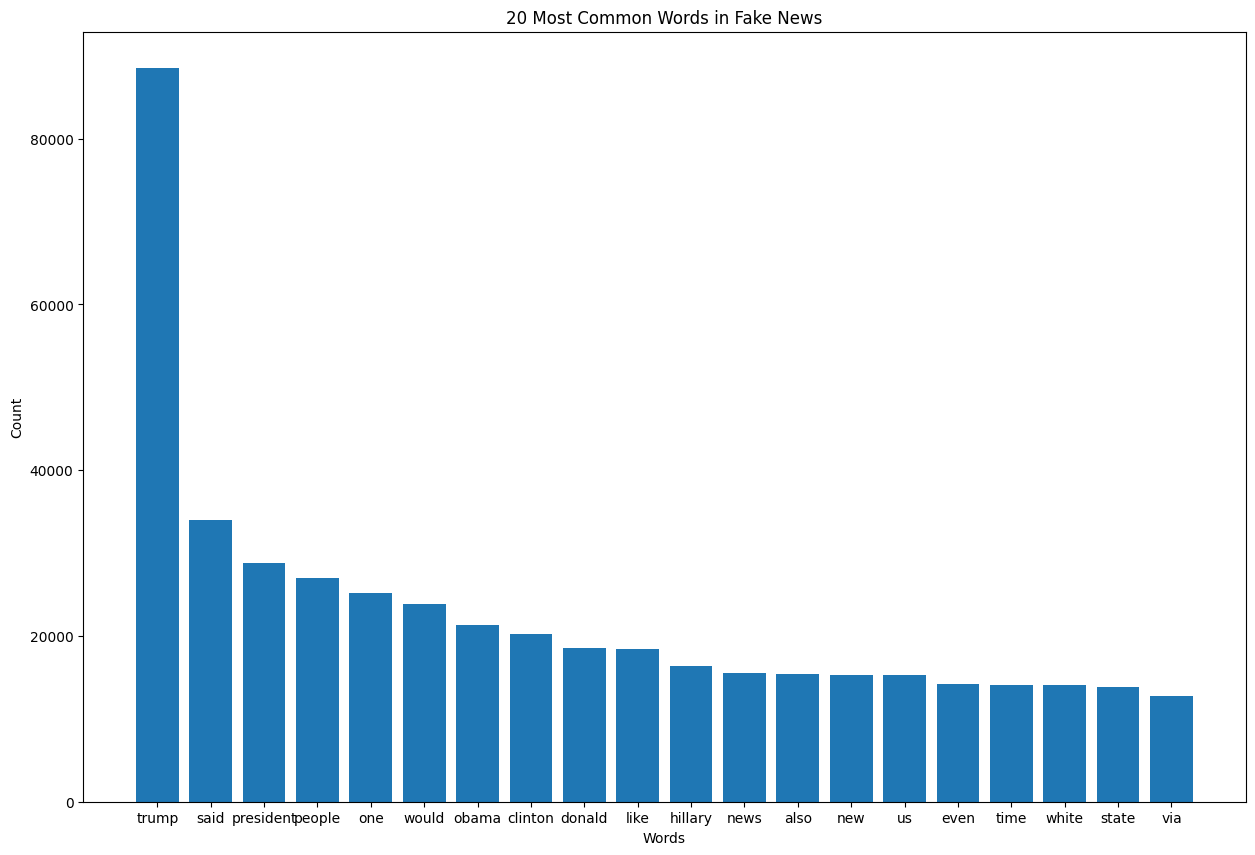

In [8]:
# most Common Words
from collections import Counter
fake_words=' '.join(df[df['label']=='FAKE']['clean_content'])


fake_words.split()
common_fake_words=Counter(fake_words.split()).most_common(20)
words,counts=zip(*common_fake_words)
plt.figure(figsize=(15,10))
plt.bar(words,counts)
plt.title("20 Most Common Words in Fake News")
plt.xlabel("Words")
plt.ylabel("Count")


Text(0, 0.5, 'Count')

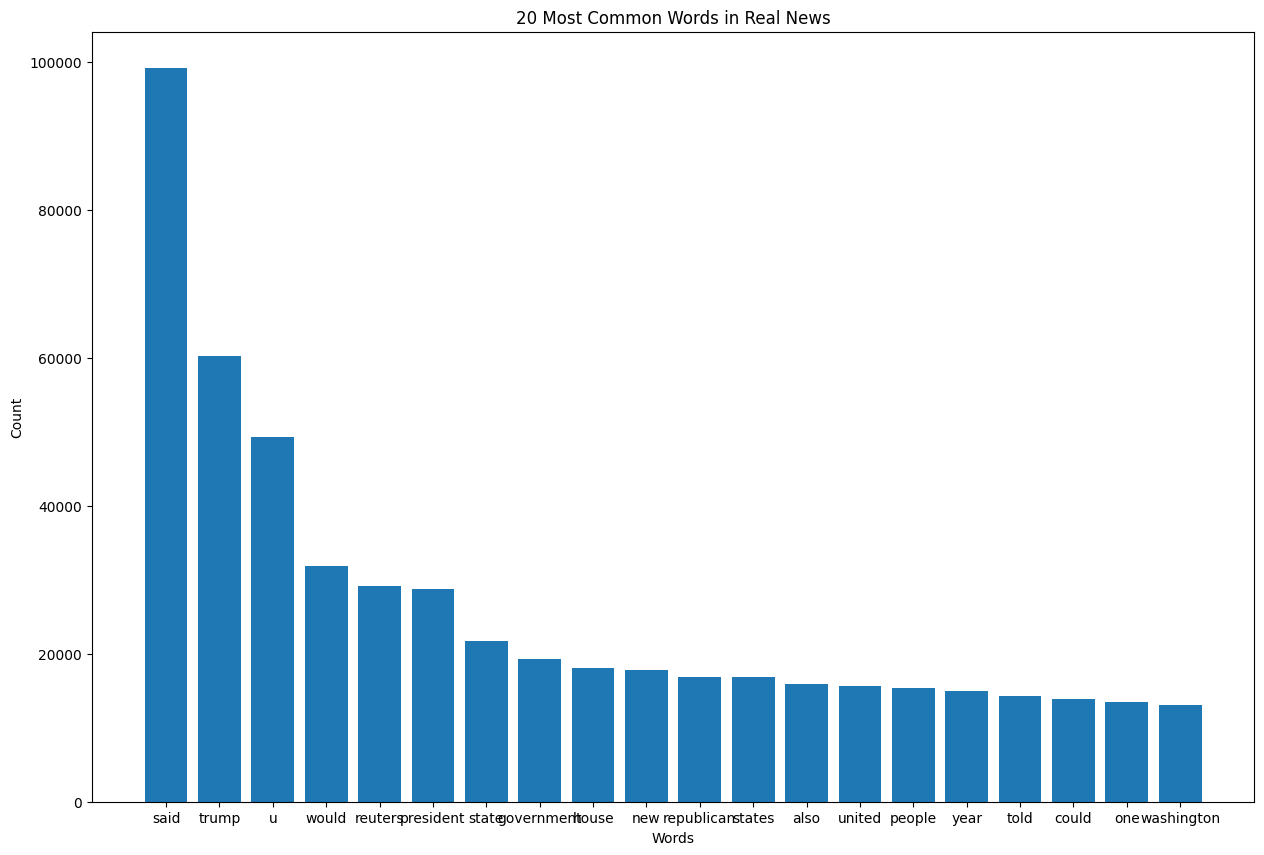

In [10]:
# most Common Words
from collections import Counter

real_words=' '.join(df[df['label']=='REAL']['clean_content'])


real_words.split()
common_real_words=Counter(real_words.split()).most_common(20)
words,counts=zip(*common_real_words)
plt.figure(figsize=(15,10))
plt.bar(words,counts)
plt.title("20 Most Common Words in Real News")
plt.xlabel("Words")
plt.ylabel("Count")

# TF-IDF Analysis
term frequency inverse document frequency

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',max_df=0.7,max_features=300)
X_tfdif=tfidf.fit_transform(df['clean_content'])
df['label_num']=df['label'].map({'FAKE':0,'REAL':1})

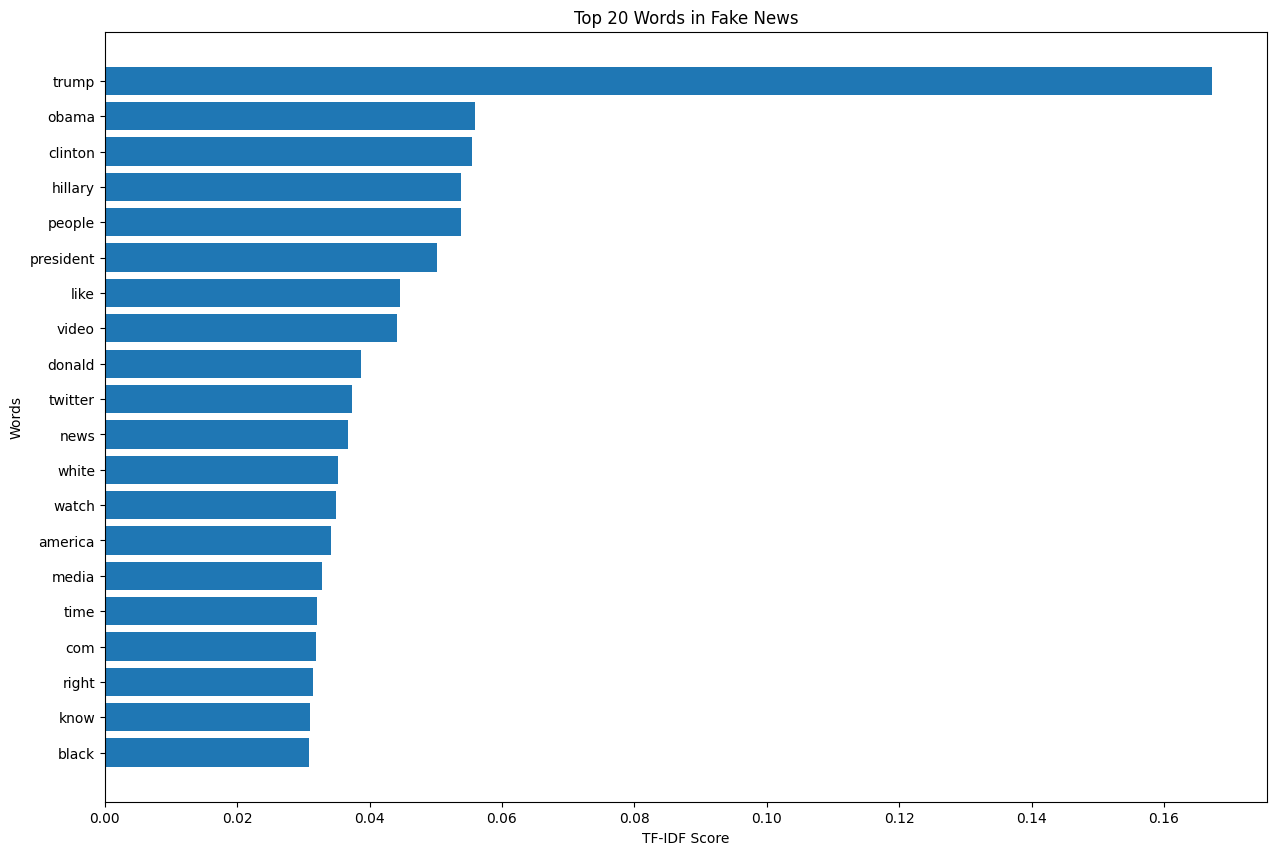

In [12]:
import numpy as np
import matplotlib.pyplot as plt
fake_idx=df[df['label_num']==0].index
fake_tfidf=X_tfdif[fake_idx].mean(axis=0)
fake_scores = np.squeeze(np.asarray(fake_tfidf))
top_fake_indices=fake_scores.argsort()[::-1][:20]
top_fake_words=[tfidf.get_feature_names_out()[i] for i in top_fake_indices]
top_fake_scores=[fake_scores[i] for i in top_fake_indices]
plt.figure(figsize=(15,10))
plt.barh(top_fake_words[::-1],top_fake_scores[::-1])
plt.title("Top 20 Words in Fake News")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()

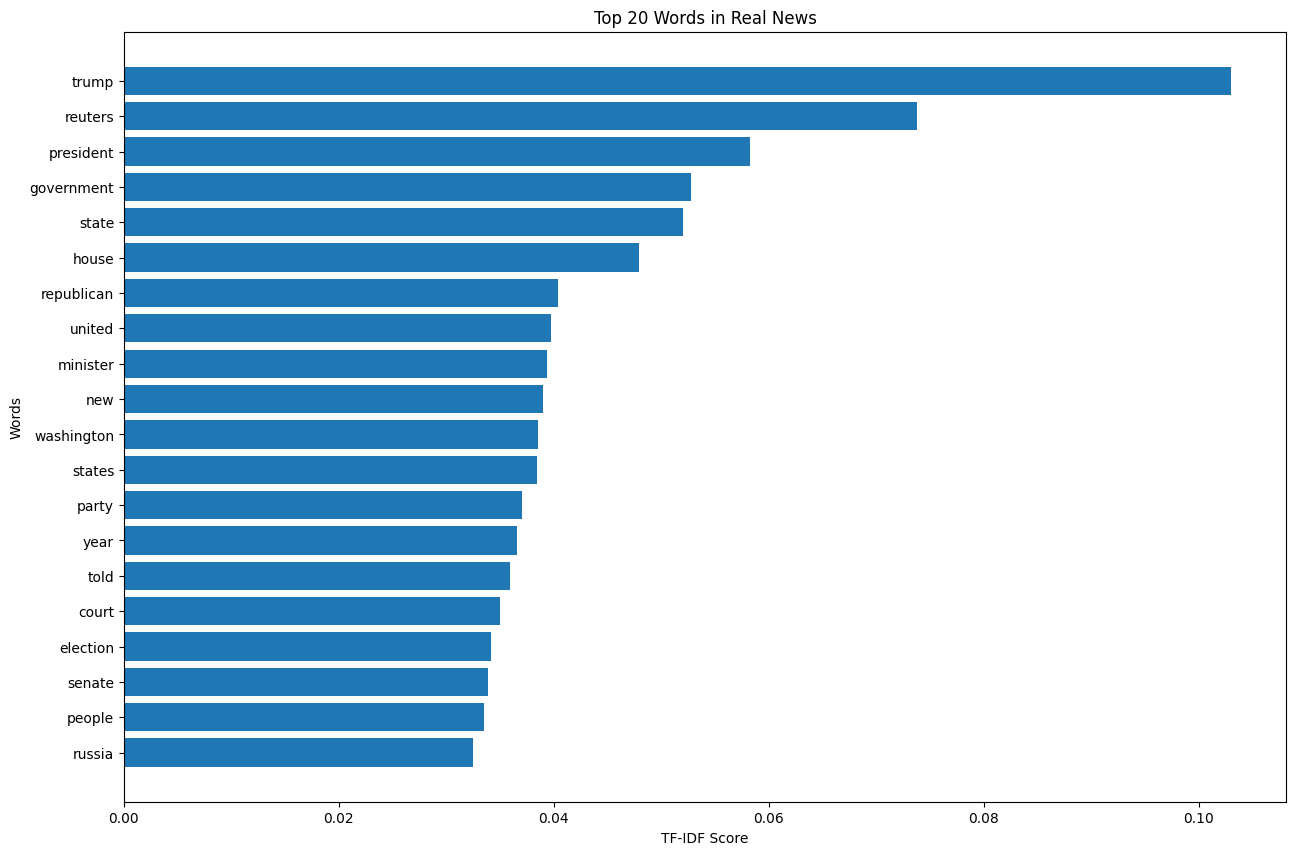

In [13]:
import numpy as np
import matplotlib.pyplot as plt
real_idx=df[df['label_num']==1].index
real_tfidf=X_tfdif[real_idx].mean(axis=0)
real_scores = np.squeeze(np.asarray(real_tfidf))
top_real_indices=real_scores.argsort()[::-1][:20]
top_real_words=[tfidf.get_feature_names_out()[i] for i in top_real_indices]
top_real_scores=[real_scores[i] for i in top_real_indices]
plt.figure(figsize=(15,10))
plt.barh(top_real_words[::-1],top_real_scores[::-1])
plt.title("Top 20 Words in Real News")
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.show()

# Logistic Regression Model

Import libraries

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

split dataset

In [15]:
X=X_tfdif
y=df['label_num']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)


Train model

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
y_pred=model.predict(X_test)

In [18]:
print("Accuracy : ",accuracy_score(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix : \n",cm)
print("Classification Report : \n",classification_report(y_test,y_pred))

Accuracy :  0.9804008908685968
Confusion Matrix : 
 [[4615   95]
 [  81 4189]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      4710
           1       0.98      0.98      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



when model says a news is fake it is right 98% of the time and it found 98% real articles correctly.

MODEL INTERPRETATION
understanding how model is predicting

In [19]:
feature_names=tfidf.get_feature_names_out()
coefs = model.coef_[0]

In [20]:
top_fake_indices = coefs.argsort()[:20]
top_fake_words = [(feature_names[i], coefs[i]) for i in top_fake_indices]
top_real_indices = coefs.argsort()[::-1][:20]
top_real_words = [(feature_names[i], coefs[i]) for i in top_real_indices]

print("Top 20 words predicting FAKE:\n", top_fake_words)
print("\nTop 20 words predicting REAL:\n", top_real_words)

Top 20 words predicting FAKE:
 [('featured', -9.123292876374048), ('image', -8.354494858820955), ('gop', -7.749090108400656), ('watch', -6.2504258875416925), ('com', -6.082430009262576), ('hillary', -5.794763570036597), ('pic', -5.025610743251002), ('america', -4.409362818740707), ('like', -4.2529161678864185), ('fact', -3.678595914109248), ('actually', -3.667218504877353), ('american', -3.4414032914956736), ('video', -3.3302819143276237), ('according', -3.266516321814325), ('story', -3.2638979361879663), ('went', -2.834901251120101), ('today', -2.804018600253901), ('really', -2.7361072907225337), ('know', -2.665425534025579), ('thing', -2.543895891752404)]

Top 20 words predicting REAL:
 [('reuters', 40.96590415307742), ('tuesday', 4.600315227491779), ('thursday', 4.5966427490941), ('wednesday', 4.581689072632967), ('washington', 4.25192574631926), ('republican', 4.195512548975907), ('friday', 4.1875938528202035), ('minister', 4.160511097708054), ('monday', 3.9790572888230225), ('talk

In [ ]:
import joblib 
joblib.dump(tfidf,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [22]:
joblib.dump(model,"logistic_model.pkl")

['logistic_model.pkl']